# Notebook for stock analysis

In [1]:
import sys
import os

# function/function.py を import できるようにパスを追加
sys.path.append(os.path.join(os.getcwd(), "function"))

import pandas as pd
pd.set_option("display.max_columns", None)

from function import YFinance_analysis
from multiple import StockValuation

## 0. 対象銘柄の定義

`ticker_list` は `(ticker, sector)` のタプルのリストとして定義する。
今回は東京証券取引所上場の以下4銘柄でテストする。

- ファナック (6954.T) / 安川電機 (6506.T) : 機械(ロボット)セクター
- トヨタ自動車 (7203.T) / SUBARU (7270.T) : 自動車セクター

In [2]:
ticker_list = [
    ("6954.T", "機械(ロボット)"),   # ファナック
    ("6506.T", "機械(ロボット)"),   # 安川電機
    ("7203.T", "自動車"),           # トヨタ自動車
    ("7270.T", "自動車"),           # SUBARU
]

analysis = YFinance_analysis(ticker_list)
analysis

## 1. 取得・計算 (Obtaining / Calculating)

各tickerについて yFinance から財務諸表(貸借対照表・損益計算書)を取得し、
PER・PBR・ROE・ROA・売上高・ATO・財務レバレッジ・ICR・Profit margin・ROS・
固定資産回転率・運転資本・CCC(DIO/DSO/DPOも含む)・流動比率・当座比率・
固定比率・固定長期適合率・自己資本比率・CAGR を年度別に計算する。

In [3]:
metrics = analysis.obtain_all()

# ファナックの年度別指標を確認
metrics["6954.T"]

,revenue,roe,roa,ato,financial_leverage,icr,profit_margin,ros,fixed_asset_turnover,working_capital,inventory,receivables,payables,dio,dso,dpo,ccc,current_ratio,quick_ratio,fixed_ratio,fixed_long_term_ratio,equity_ratio,per,pbr,cagr,ticker
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-03-31,8.519560e+11,0.105602,0.091051,0.454732,1.159814,NaN,0.200230,0.224611,1.049471,8.777850e+11,3.505770e+11,1.627850e+11,5.693500e+10,243.017468,69.741307,39.466935,273.291841,5.771738,3.865962,0.502543,0.483960,0.862207,24.928838,2.632536,0.002293,6954.T
2024-03-31,7.952740e+11,0.078074,0.069136,0.412907,1.129272,NaN,0.167438,0.178453,0.935868,9.193750e+11,3.625460e+11,1.559210e+11,4.293800e+10,254.758659,71.561707,30.172247,296.148119,6.859997,4.549168,0.498238,0.484062,0.885526,28.463409,2.222242,0.002293,6954.T
2025-03-31,7.971290e+11,0.085563,0.076177,0.411521,1.123213,NaN,0.185111,0.199273,0.936428,9.282010e+11,3.064390e+11,1.564370e+11,3.745400e+10,222.718726,71.631449,27.221428,267.128747,6.890123,4.945541,0.493605,0.482537,0.890303,25.125405,2.149801,0.002293,6954.T
2026-03-31,8.578310e+11,0.089305,0.079659,0.410308,1.121096,NaN,0.194144,0.214218,1.004870,1.057569e+12,2.921860e+11,1.707750e+11,4.626200e+10,201.463810,72.663351,31.897897,242.229265,6.893161,5.264994,0.457766,0.450924,0.891984,29.707691,2.653056,0.002293,6954.T


## 2. 統合 (Merging)

各tickerのDataFrameに業界(sector)ラベルを付与して1つのDataFrameに統合する。

In [4]:
merged_df = analysis.merge()
merged_df.head()

,date,revenue,roe,roa,ato,financial_leverage,icr,profit_margin,ros,fixed_asset_turnover,working_capital,inventory,receivables,payables,dio,dso,dpo,ccc,current_ratio,quick_ratio,fixed_ratio,fixed_long_term_ratio,equity_ratio,per,pbr,cagr,ticker,sector
0,2023-03-31,8.519560e+11,0.105602,0.091051,0.454732,1.159814,NaN,0.200230,0.224611,1.049471,8.777850e+11,3.505770e+11,1.627850e+11,5.693500e+10,243.017468,69.741307,39.466935,273.291841,5.771738,3.865962,0.502543,0.483960,0.862207,24.928838,2.632536,0.002293,6954.T,機械(ロボット)
1,2024-03-31,7.952740e+11,0.078074,0.069136,0.412907,1.129272,NaN,0.167438,0.178453,0.935868,9.193750e+11,3.625460e+11,1.559210e+11,4.293800e+10,254.758659,71.561707,30.172247,296.148119,6.859997,4.549168,0.498238,0.484062,0.885526,28.463409,2.222242,0.002293,6954.T,機械(ロボット)
2,2025-03-31,7.971290e+11,0.085563,0.076177,0.411521,1.123213,NaN,0.185111,0.199273,0.936428,9.282010e+11,3.064390e+11,1.564370e+11,3.745400e+10,222.718726,71.631449,27.221428,267.128747,6.890123,4.945541,0.493605,0.482537,0.890303,25.125405,2.149801,0.002293,6954.T,機械(ロボット)
3,2026-03-31,8.578310e+11,0.089305,0.079659,0.410308,1.121096,NaN,0.194144,0.214218,1.004870,1.057569e+12,2.921860e+11,1.707750e+11,4.626200e+10,201.463810,72.663351,31.897897,242.229265,6.893161,5.264994,0.457766,0.450924,0.891984,29.707691,2.653056,0.002293,6954.T,機械(ロボット)
4,2023-02-28,5.559550e+11,0.149016,0.079284,0.851214,1.879522,30.775638,0.093142,0.122853,2.501676,2.160880e+11,1.822260e+11,1.712190e+11,6.771600e+10,182.752728,112.410060,67.911735,227.251054,2.005949,1.157637,0.639521,0.588108,0.532050,25.912426,3.861373,-0.008364,6506.T,機械(ロボット)


## 3. 可視化 (Plotting)

`by_sector` に True / False を渡すことで、業界ごとに分けて比較するか、
全銘柄をまとめて比較するかを切り替えられる。

### 3-1. 全銘柄まとめて比較 (`by_sector=False`)

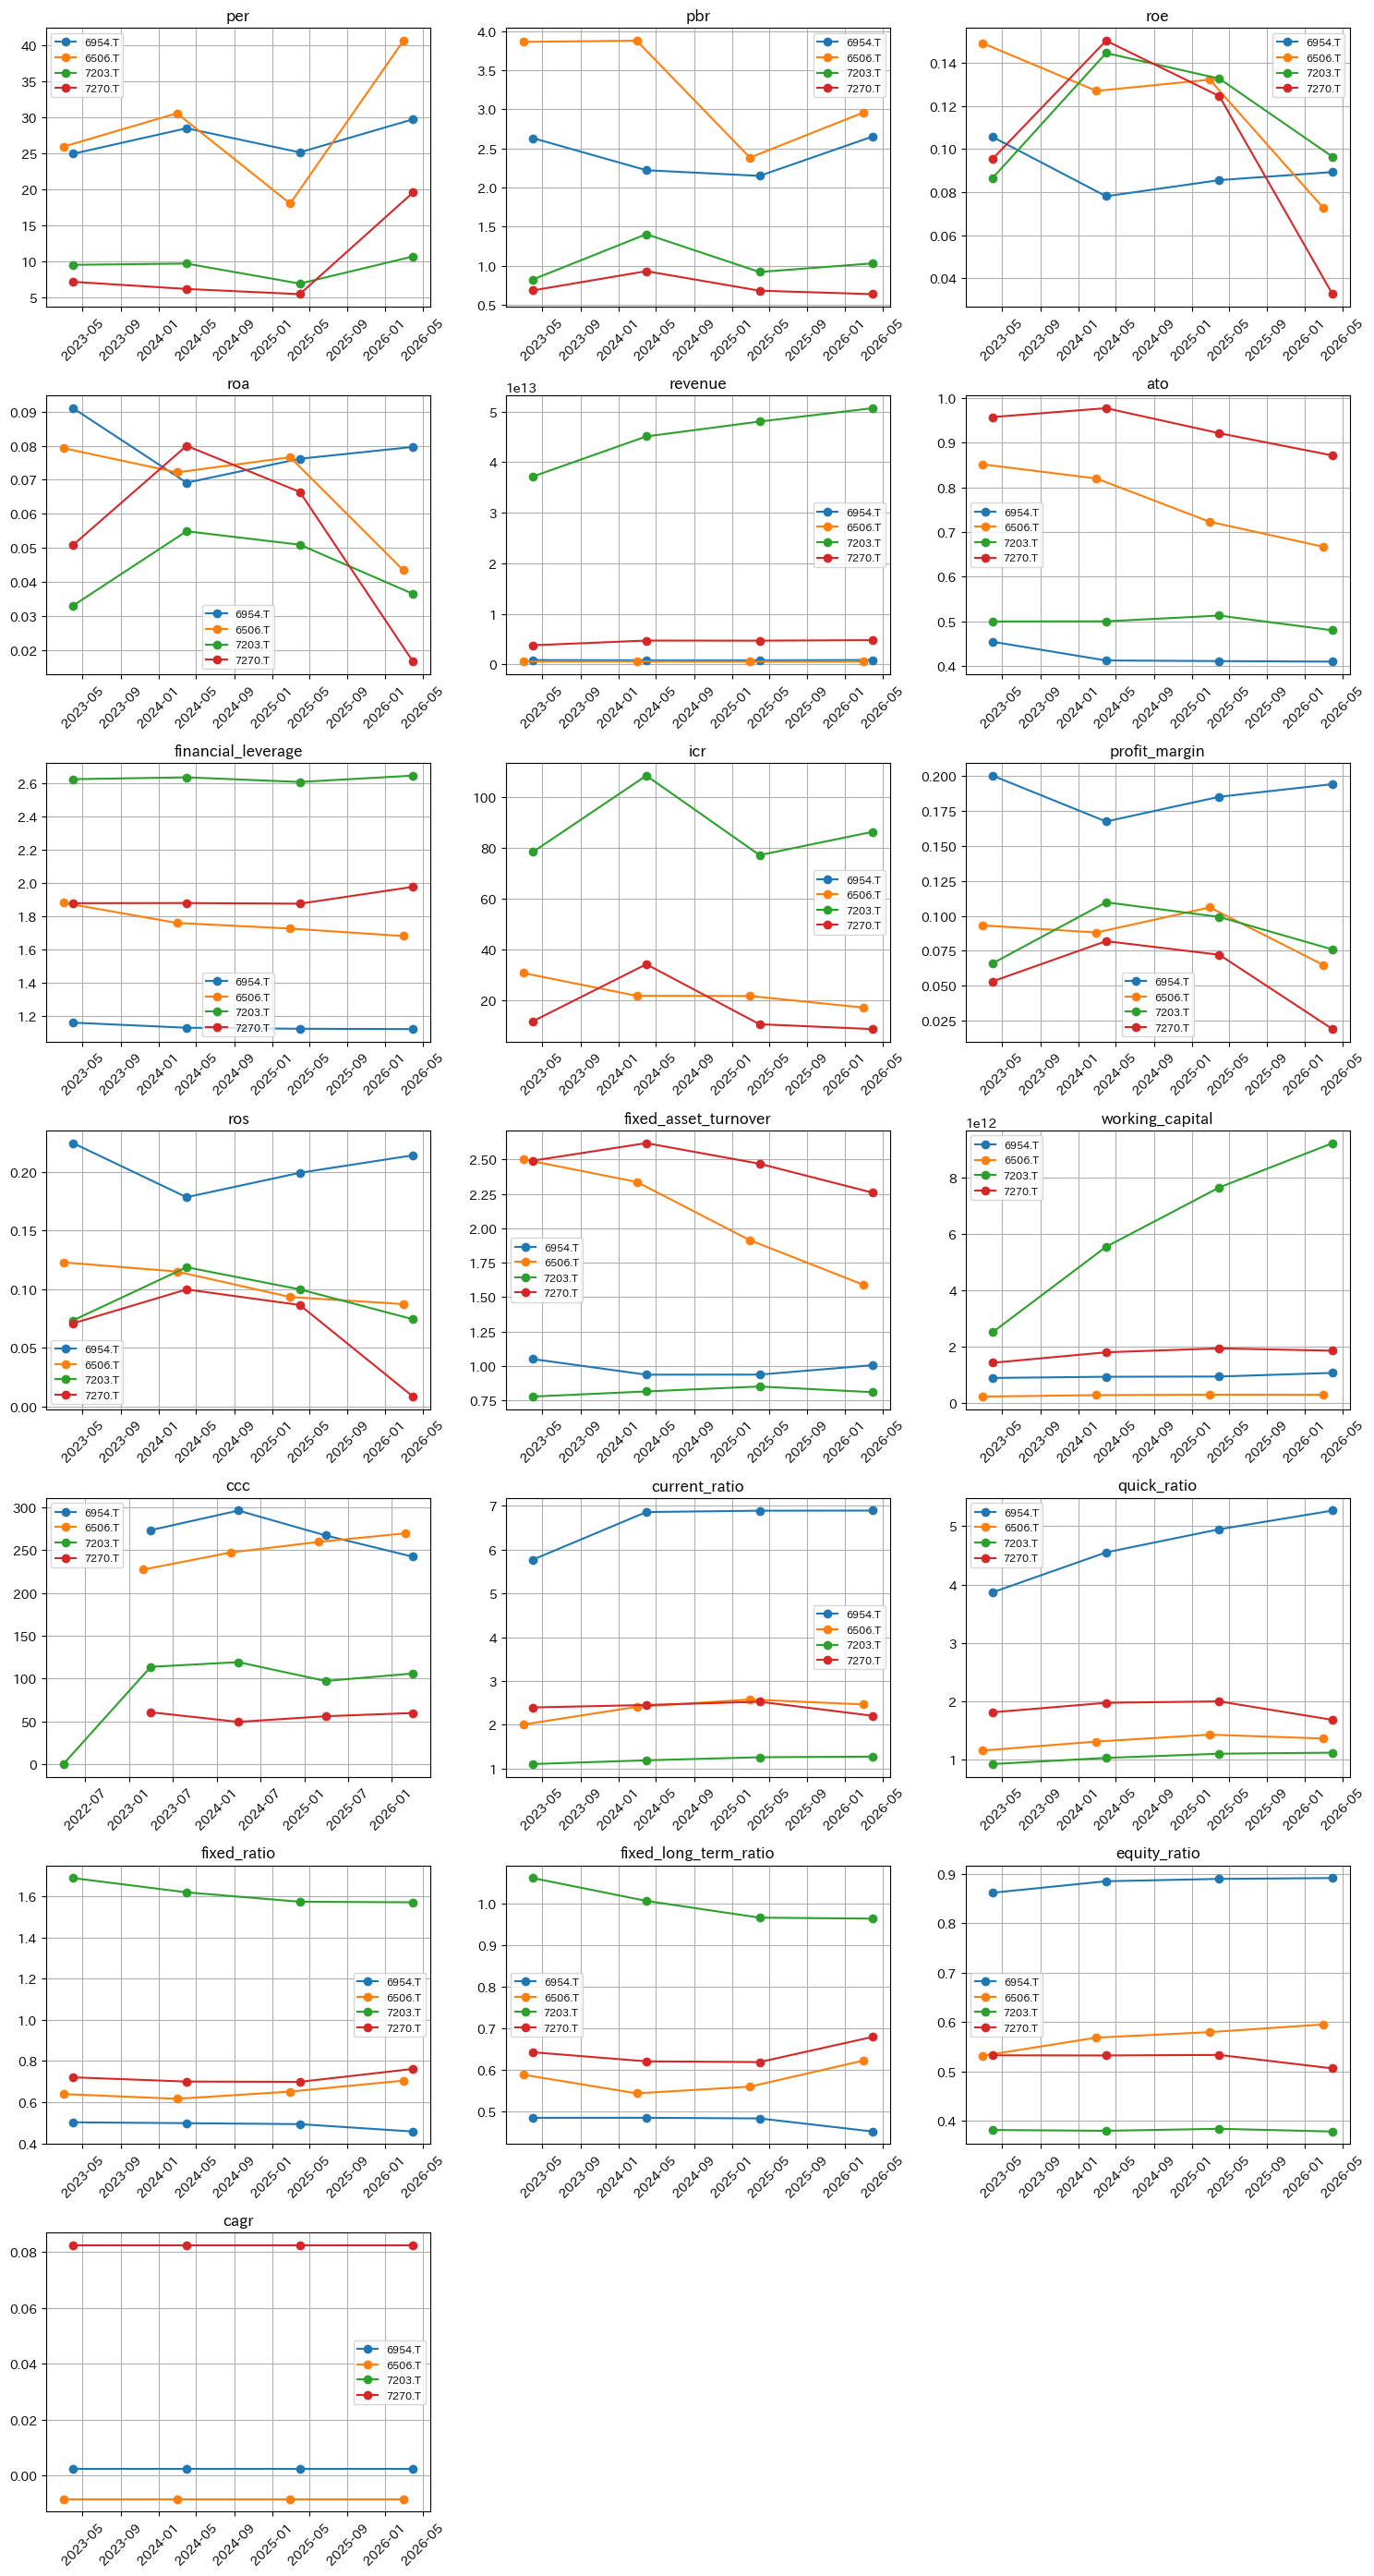

(<Figure size 1500x2800 with 21 Axes>,
 array([[<Axes: title={'center': 'per'}>, <Axes: title={'center': 'pbr'}>,
         <Axes: title={'center': 'roe'}>],
        [<Axes: title={'center': 'roa'}>,
         <Axes: title={'center': 'revenue'}>,
         <Axes: title={'center': 'ato'}>],
        [<Axes: title={'center': 'financial_leverage'}>,
         <Axes: title={'center': 'icr'}>,
         <Axes: title={'center': 'profit_margin'}>],
        [<Axes: title={'center': 'ros'}>,
         <Axes: title={'center': 'fixed_asset_turnover'}>,
         <Axes: title={'center': 'working_capital'}>],
        [<Axes: title={'center': 'ccc'}>,
         <Axes: title={'center': 'current_ratio'}>,
         <Axes: title={'center': 'quick_ratio'}>],
        [<Axes: title={'center': 'fixed_ratio'}>,
         <Axes: title={'center': 'fixed_long_term_ratio'}>,
         <Axes: title={'center': 'equity_ratio'}>],
        [<Axes: title={'center': 'cagr'}>, <Axes: >, <Axes: >]],
       dtype=object))

In [5]:
analysis.plot(by_sector=False)

### 3-2. 業界ごとに分けて比較 (`by_sector=True`)

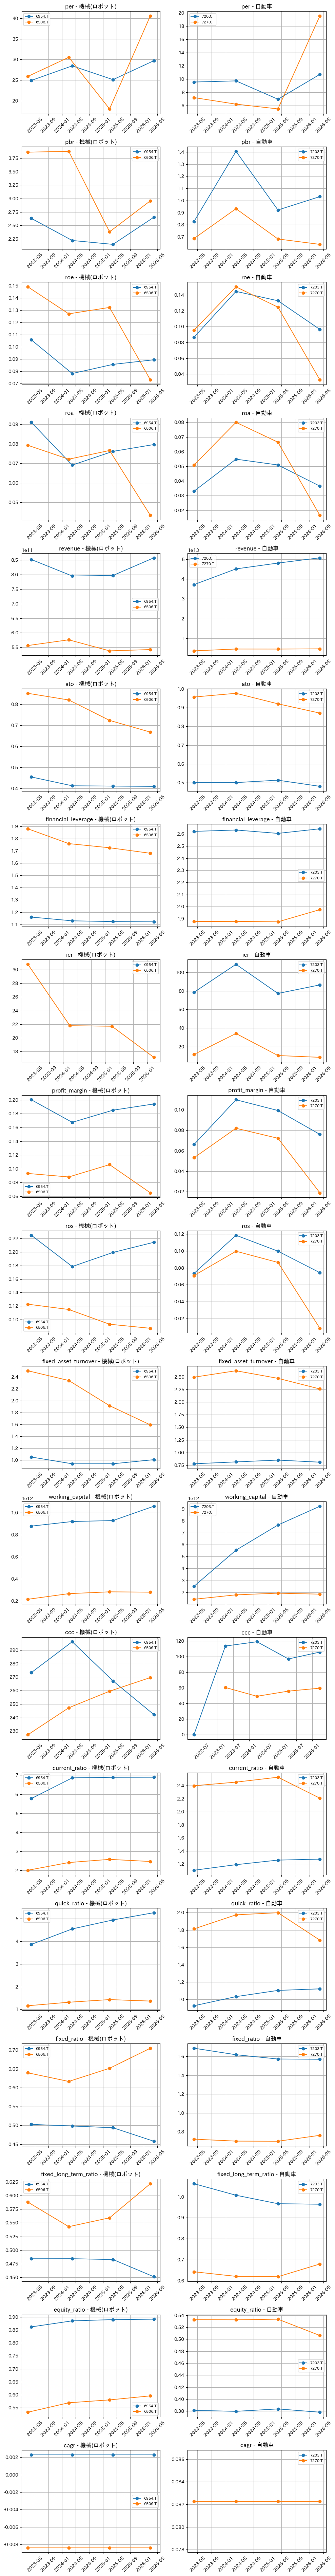

(<Figure size 1000x7600 with 38 Axes>,
 array([[<Axes: title={'center': 'per - 機械(ロボット)'}>,
         <Axes: title={'center': 'per - 自動車'}>],
        [<Axes: title={'center': 'pbr - 機械(ロボット)'}>,
         <Axes: title={'center': 'pbr - 自動車'}>],
        [<Axes: title={'center': 'roe - 機械(ロボット)'}>,
         <Axes: title={'center': 'roe - 自動車'}>],
        [<Axes: title={'center': 'roa - 機械(ロボット)'}>,
         <Axes: title={'center': 'roa - 自動車'}>],
        [<Axes: title={'center': 'revenue - 機械(ロボット)'}>,
         <Axes: title={'center': 'revenue - 自動車'}>],
        [<Axes: title={'center': 'ato - 機械(ロボット)'}>,
         <Axes: title={'center': 'ato - 自動車'}>],
        [<Axes: title={'center': 'financial_leverage - 機械(ロボット)'}>,
         <Axes: title={'center': 'financial_leverage - 自動車'}>],
        [<Axes: title={'center': 'icr - 機械(ロボット)'}>,
         <Axes: title={'center': 'icr - 自動車'}>],
        [<Axes: title={'center': 'profit_margin - 機械(ロボット)'}>,
         <Axes: title={'center': 'profit_mar

In [6]:
analysis.plot(by_sector=True)

## 4. 特定の指標だけを見たい場合

`metrics` 引数に指標名のリストを渡すと、その指標だけをプロットできる。
指標名は `merged_df.columns` を参照。

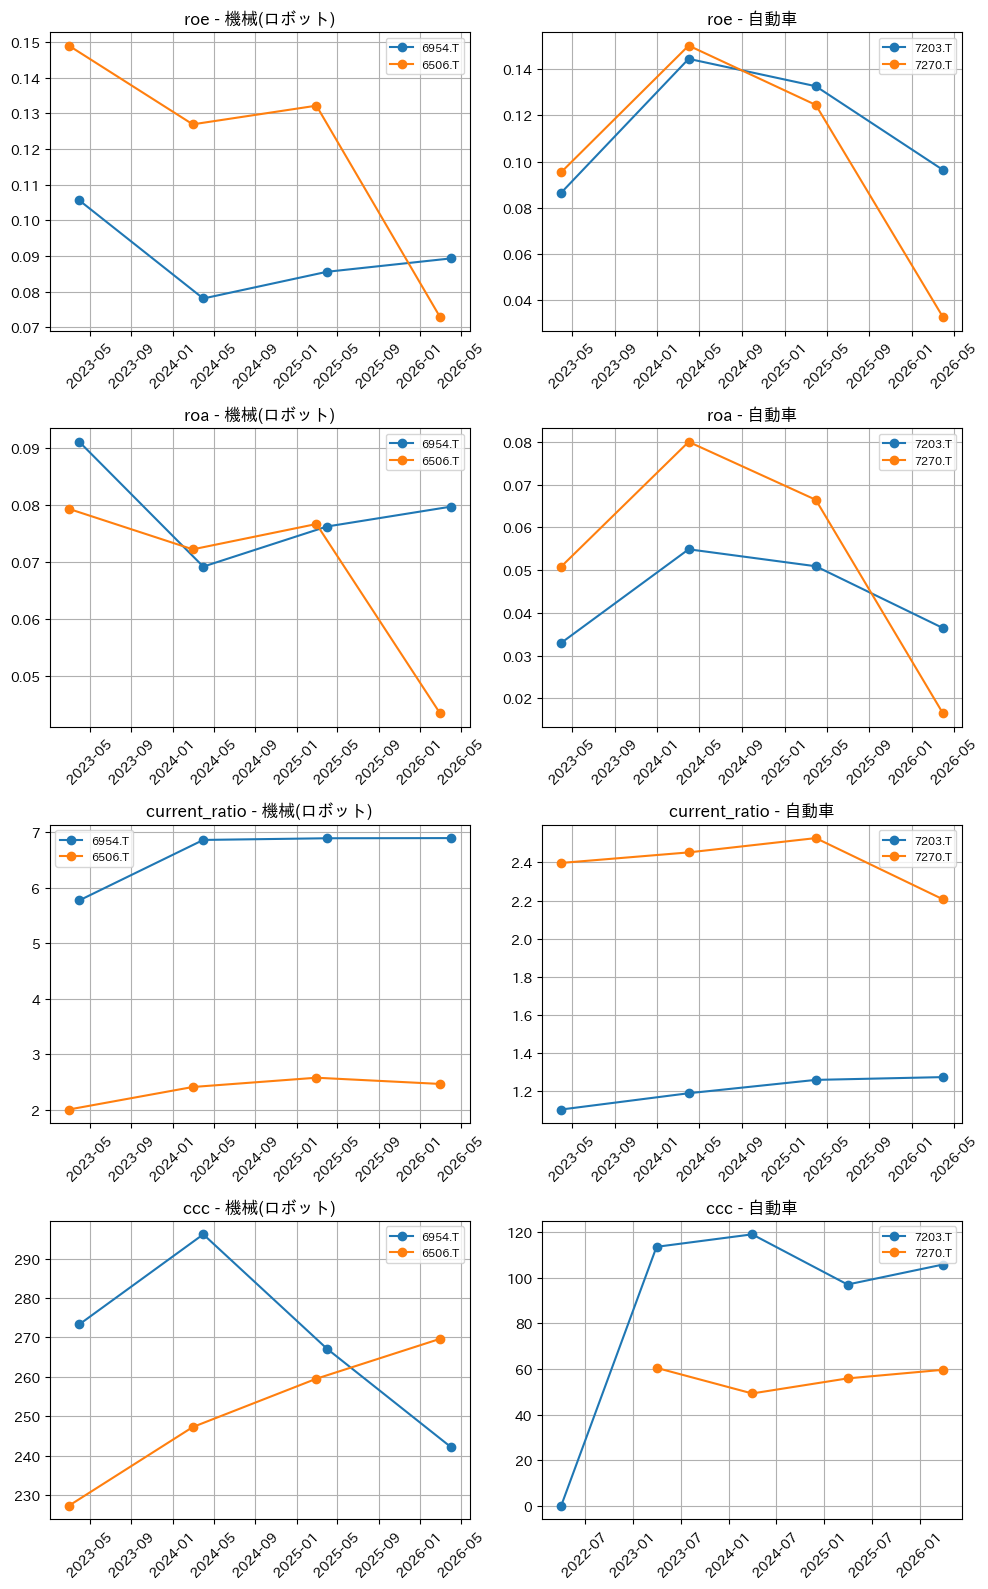

(<Figure size 1000x1600 with 8 Axes>,
 array([[<Axes: title={'center': 'roe - 機械(ロボット)'}>,
         <Axes: title={'center': 'roe - 自動車'}>],
        [<Axes: title={'center': 'roa - 機械(ロボット)'}>,
         <Axes: title={'center': 'roa - 自動車'}>],
        [<Axes: title={'center': 'current_ratio - 機械(ロボット)'}>,
         <Axes: title={'center': 'current_ratio - 自動車'}>],
        [<Axes: title={'center': 'ccc - 機械(ロボット)'}>,
         <Axes: title={'center': 'ccc - 自動車'}>]], dtype=object))

In [7]:
analysis.plot(by_sector=True, metrics=["roe", "roa", "current_ratio", "ccc"])

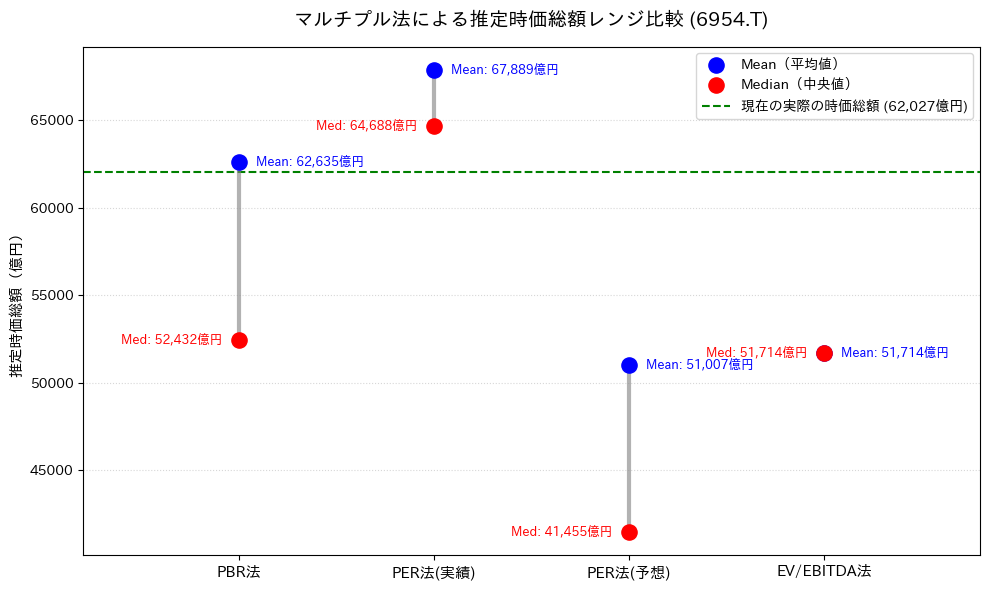

In [2]:
ticker_list = [
        ("6954.T", "FA/ロボット"),  # ファナック
        ("6506.T", "FA/ロボット"),  # 安川電機
        ("6645.T", "制御機器"),     # オムロン
        ("6861.T", "FA/センサー")   # キーエンス
    ]

# インスタンス化と実行
valuation = StockValuation(ticker_list, main_ticker="6954.T")

# 1. 推定数値の計算
est_df = valuation.estimation()

# 2. 縦線グラフのプロット
valuation.plot_estimation_range(est_df)

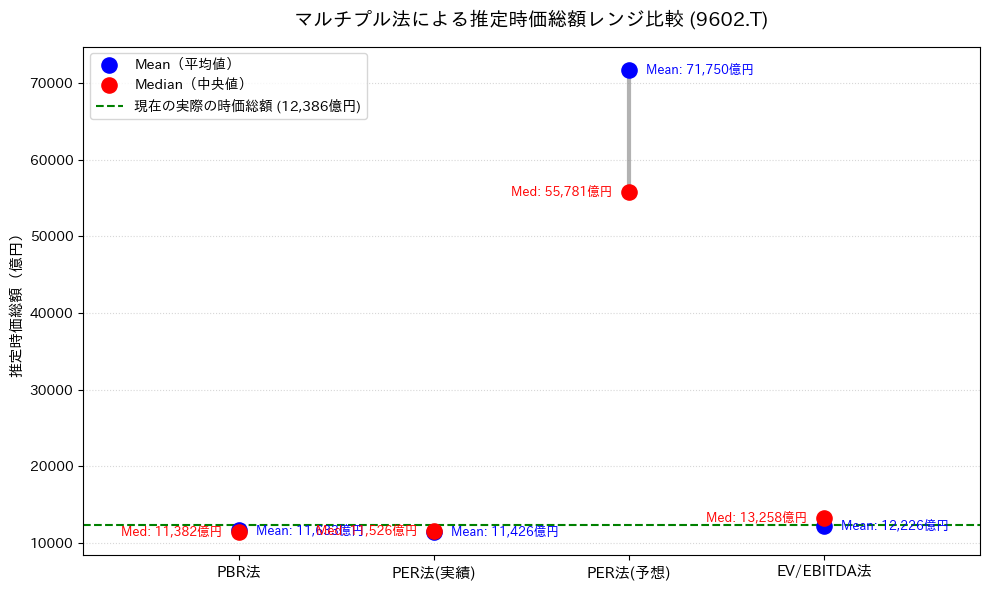

In [6]:
ticker_list = [
        ("7974.T", "Game"),  # Nintendo
        ("4816.T", "Anime"), # Toei anime
        ("9601.T", "Entertainment"), #竹松
        ("9602.T", "Movies"), #Toho
        ("9605.T", "Anime") # Toei
    
    ]

# インスタンス化と実行
valuation = StockValuation(ticker_list, main_ticker="9602.T")

# 1. 推定数値の計算
est_df = valuation.estimation()

# 2. 縦線グラフのプロット
valuation.plot_estimation_range(est_df)

In [4]:
est_df

,mean,median
PBR法,11632.785798,11382.106038
PER法(実績),11426.276250,11526.103046
PER法(予想),71750.131434,55781.267662
EV/EBITDA法,12226.011323,13257.651377
